# Activity Analysis: Th-228 Stability Tracking

This notebook demonstrates **activity analysis** for time-resolved alpha spectra:

1. **Load time-stamped spectra** from individual sets (not aggregated)
2. **Extract Th-228 counts** using the specified energy range
3. **Calculate activity** [Bq] from count rates (with efficiency/branching corrections)
4. **Fit decay curve** (expected to be flat due to long half-life)
5. **Visualize** activity evolution over ~2 days

## Physics Background

**Th-232 Decay Chain:**
```
Th-228 (1.9 y) --α(5.42 MeV)--> Ra-224 (3.6 d) --α(5.69 MeV)--> Rn-220 (55 s) --> ...
```

**Why Th-228?**
- T½ = 1.9 years → Should be constant over a 2-day measurement window
- Good for checking detector stability and gain shifts
- Branching ratio: 71.7% (main α line)
- Target Energy Range: [5.134, 5.543] MeV

**RUN18 Dataset:**
- 12 measurement sets (FieldScan_Gate0050_Anode1950, etc.)
- Total time span: ~2 days

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from RaTag.core.datatypes import Run
from RaTag.workflows.run_construction import initialize_run

# Spectrum fitting
from RaTag.alphas.spectrum_fitting import (
    load_spectrum_from_run,
    fit_multi_crystalball_progressive,
    derive_energy_calibration,
    IsotopeRange,
)

# Activity analysis
from RaTag.alphas.activity_analysis import (
    load_all_timestamped_spectra,
    measure_activity_timeseries,
    fit_exponential_decay,
    HALF_LIVES,
    BRANCHING_RATIOS,
    TimeStampedSpectrum
)

# Activity plotting
from RaTag.alphas.activity_plotting import (
    plot_activity_timeseries,
    plot_count_rate_timeseries,
    plot_activity_diagnostic,
)
from RaTag.alphas.spectrum_fitting import SpectrumData

## Step 1: Initialize Run

In [3]:
# Define run
path_multi = Path('/Volumes/KINGSTON/RaTag_data/RUN18')

run = Run(
    run_id="RUN18",
    root_directory=path_multi,
    target_isotope="Multi",
    pressure=2.0,
    temperature=297.0,
    sampling_rate=5.0,
    drift_gap=1.4,
    el_gap=0.8,
    el_field=2375.0,
    sets=[]
)

# Initialize (populates sets, computes fields)
run = initialize_run(run)

print(f"Loaded run with {len(run.sets)} sets")


RUN INITIALIZATION

[1/3] Gas density...
  ✓ Gas density: 4.877e+19 cm⁻³

[2/3] Populating sets...
Detected multi-isotope files...
  Loaded: FieldScan_Gate0050_Anode1950 - 3800 files (182400 waveforms) [FastFrame (48 frames/file)]
Detected multi-isotope files...
  Loaded: FieldScan_Gate0100_Anode2000 - 4000 files (192000 waveforms) [FastFrame (48 frames/file)]
Detected multi-isotope files...
  Loaded: FieldScan_Gate0200_Anode2100 - 4000 files (192000 waveforms) [FastFrame (48 frames/file)]
Detected multi-isotope files...
  Loaded: FieldScan_Gate0300_Anode2200 - 4000 files (192000 waveforms) [FastFrame (48 frames/file)]
Detected multi-isotope files...
  Loaded: FieldScan_Gate0400_Anode2300 - 4000 files (192000 waveforms) [FastFrame (48 frames/file)]
Detected multi-isotope files...
  Loaded: FieldScan_Gate0500_Anode2400 - 4001 files (192048 waveforms) [FastFrame (48 frames/file)]
Detected multi-isotope files...
  Loaded: FieldScan_Gate0600_Anode2500 - 4000 files (192000 waveforms) [Fast

## Step 2: Define Th-228 Range

We will use the user-provided range: `[5.134, 5.543] MeV`.

In [ ]:
th228_tail_min = 2.0  # Extend tail to 2 MeV to capture more of the spectrum for better fitting
th228_E_min = 5.134
th228_E_max = 5.543
th228_ref_energy = 5.42315

# Create IsotopeRange object for compatibility with measure_activity()
th228_range = IsotopeRange(
    name='Th228',
    E_min=th228_tail_min,
    E_max=th228_E_max,
    E_peak=th228_ref_energy,
    sigma=(th228_E_max - th228_E_min) / 4,  # Approximate sigma
    purity=1.0
)

print(f"\n✓ Th-228 range extracted: [{th228_range.E_min:.3f}, {th228_range.E_max:.3f}] MeV")


✓ Th-228 range extracted: [2.000, 5.543] MeV


## Step 3: Load Time-Stamped Spectra

Load individual sets and apply the quadratic calibration to convert SCA units to MeV.

In [10]:
# Load all time-stamped spectra (in SCA units)
timestamped_spectra = load_all_timestamped_spectra(run, energy_range=(4, 8.2))

# Apply quadratic calibration to each spectrum to convert to MeV
calib_file = '/Volumes/KINGSTON/RaTag_data/RUN18/processed_data/spectrum_calibration/RUN18_calibration.npz'
calib_data = np.load(calib_file)
quad_a = calib_data['quad_a']
quad_b = calib_data['quad_b']
quad_c = calib_data['quad_c']

def apply_quadratic_calibration(x):
    return quad_a * x**2 + quad_b * x + quad_c


calibrated_timestamped_spectra = []
for spectrum_t in timestamped_spectra:
    spectrum = spectrum_t.spectrum
    energies_cal = apply_quadratic_calibration(np.array(spectrum.energies))
    spectrum_cal = SpectrumData(
        energies=energies_cal,
        energy_range=(4, 8.2),  # Now in MeV
        source=spectrum.source
    )
    spectrum_t_cal = TimeStampedSpectrum(
        spectrum=spectrum_cal,
        timestamp=spectrum_t.timestamp,
        set_name=spectrum_t.set_name,
        acquisition_time=spectrum_t.acquisition_time
    )
    calibrated_timestamped_spectra.append(spectrum_t_cal)

timestamped_spectra = calibrated_timestamped_spectra

print(f"Loaded {len(timestamped_spectra)} time-stamped spectra and calibrated to MeV\n")

Loaded 12 time-stamped spectra and calibrated to MeV



## Step 4: Measure Th-228 Activity Time Series

In [11]:
# Measure Th-228 activity for all time points
efficiency = 1.0  # Relative activity 
branching_ratio = BRANCHING_RATIOS['Th228']  # 0.717

th228_measurements = measure_activity_timeseries(
    timestamped_spectra,
    th228_range,
    efficiency=efficiency,
    branching_ratio=branching_ratio
)

print("="*70)
print("TH-228 ACTIVITY MEASUREMENTS")
print("="*70)
print(f"{'Time':20s} {'Counts':>8s} {'Live Time':>10s} {'Activity [Bq]':>15s}")
print("-"*70)
for m in th228_measurements:
    print(f"{m.acquisition_time.strftime('%Y-%m-%d %H:%M'):20s} "
          f"{m.counts:8d} "
          f"{m.live_time:10.2f} h "
          f"{m.activity:10.2f} ± {m.activity_err:6.2f}")
print("="*70)

TH-228 ACTIVITY MEASUREMENTS
Time                   Counts  Live Time   Activity [Bq]
----------------------------------------------------------------------
2025-11-04 13:09        51972       5.44 h       3.70 ±   0.02
2025-11-04 18:22        53646       4.91 h       4.23 ±   0.02
2025-11-05 13:54        52391       6.24 h       3.26 ±   0.01
2025-11-05 19:44        52332       5.15 h       3.94 ±   0.02
2025-11-06 13:12        51572       6.15 h       3.25 ±   0.01
2025-11-06 18:55        51989       5.19 h       3.88 ±   0.02
2025-11-07 08:01        54824       5.14 h       4.13 ±   0.02
2025-11-07 14:49        55089       5.45 h       3.92 ±   0.02
2025-11-07 20:21        54349       5.52 h       3.82 ±   0.02
2025-11-08 08:08        54114       5.36 h       3.91 ±   0.02
2025-11-08 13:54        55497       5.40 h       3.98 ±   0.02
2025-11-08 19:46        54213       5.34 h       3.94 ±   0.02


## Step 5: Fit Exponential Decay

Fit model to verify stability (since half-life is 1.9 years, it should look flat).

In [40]:
# Fit exponential decay
half_life_literature = HALF_LIVES['Th228']

decay_fit = fit_exponential_decay(th228_measurements, half_life_literature)

print("="*70)
print("EXPONENTIAL DECAY FIT RESULTS")
print("="*70)
print(f"\nIsotope: {decay_fit.isotope}")
print(f"  T½ (literature) = {decay_fit.half_life_literature/24/365.25:.2f} years")
print(f"  T½ (fitted)     = {decay_fit.half_life/24/365.25:.2f} years")
print("="*70)

EXPONENTIAL DECAY FIT RESULTS

Isotope: Th228
  T½ (literature) = 1.90 years
  T½ (fitted)     = 37548468.15 years


## Step 6: Visualize Activity vs Time

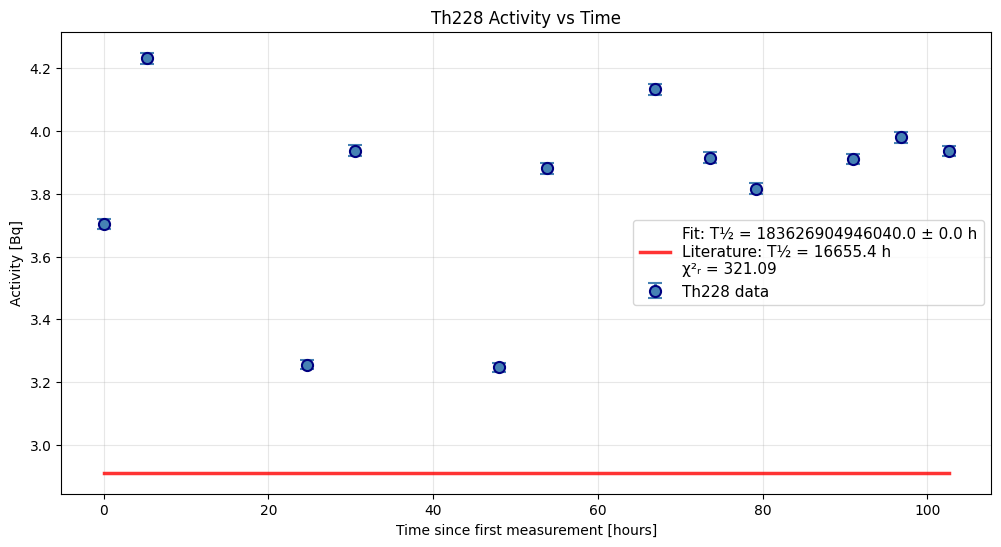

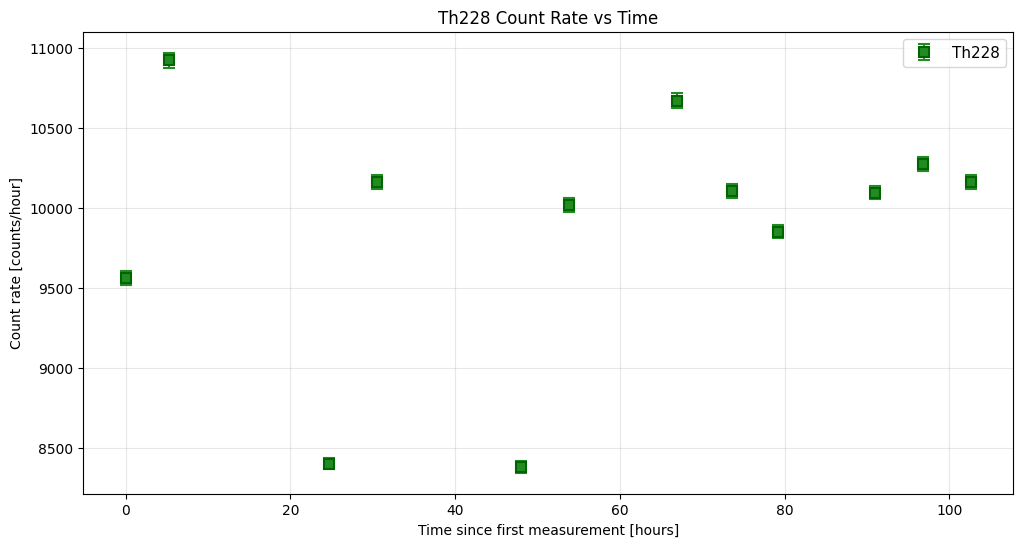

/var/folders/tb/zxwsw51n6_g6gs5lnxdv2bcr0000gn/T/ipykernel_26098/1283291302.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


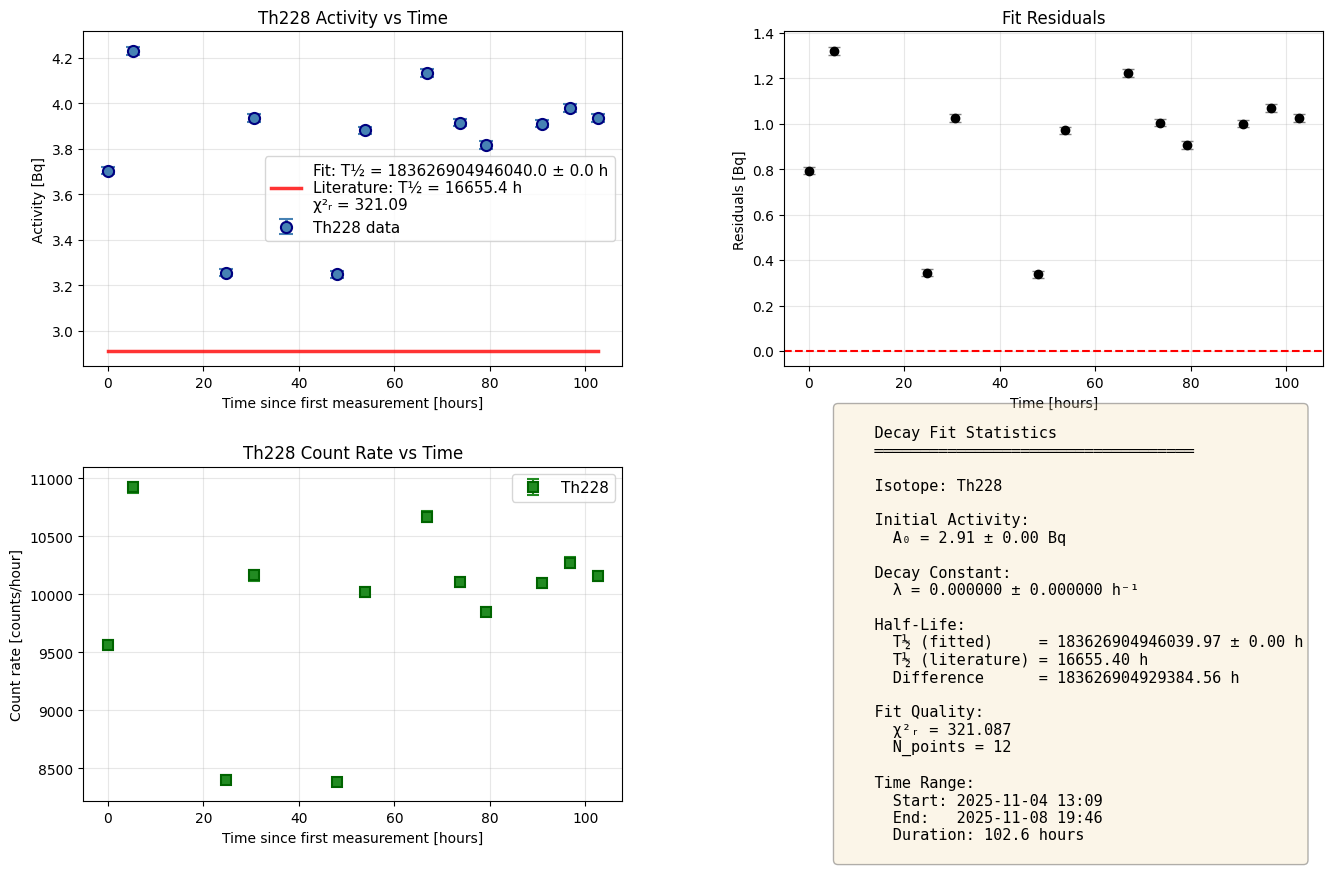

In [39]:
fig, ax = plot_activity_timeseries(th228_measurements, decay_fit, figsize=(12, 6))
plt.show()

fig, ax = plot_count_rate_timeseries(th228_measurements, figsize=(12, 6))
plt.show()

fig, axes = plot_activity_diagnostic(th228_measurements, decay_fit, figsize=(16, 10))
plt.tight_layout()
plt.show()

# Estimate deadtime by comparing to MCA data

In [35]:
filemca = '/Users/pabloherrero/sabat/RaTagging/scope_data/MCA_spectra/Second_Th_loaded_detector_in_air.csv'
dfmca = pd.read_csv(filemca, skiprows=11, nrows=2048)
mca_time = float(pd.read_csv(filemca, skiprows=9, nrows=1).columns[0].split(' ')[0])
mca_time

3600.0

(500.0, 980.0)

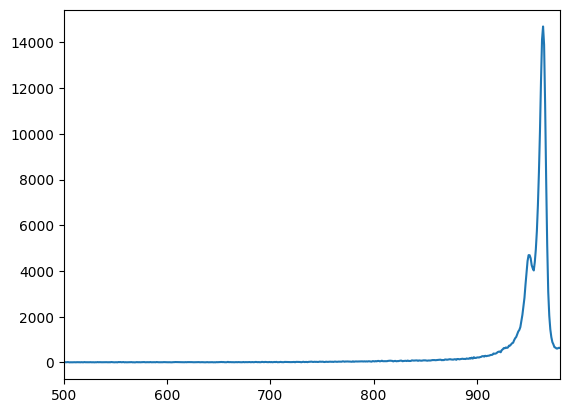

In [26]:
plt.plot(dfmca)
plt.xlim(500, 980)

In [38]:
total_counts = dfmca[300:980].sum().values[0]
activity = total_counts / mca_time
print(f"Total counts in Th-228 region: {total_counts}")
print(f"Measurement time: {mca_time} seconds")
print(f"Estimated activity: {activity:.2f} Bq")

Total counts in Th-228 region: 222635
Measurement time: 3600.0 seconds
Estimated activity: 61.84 Bq


In [4]:
filemca = '/Users/pabloherrero/sabat/RaTagging/scope_data/MCA_spectra/After_collection_Al_activity_Th228_P1.csv'
dfmca = pd.read_csv(filemca, skiprows=11, nrows=2048)
mca_time = float(pd.read_csv(filemca, skiprows=9, nrows=1).columns[0].split(' ')[0])
mca_time

901.0

In [ ]:
import datetime
mca_date_str = pd.read_csv(filemca, skiprows=7, nrows=1).columns[0].split(' ')[0]
mca_date = datetime.datetime.strptime(mca_date_str, "%m/%d/%Y")


datetime.datetime(2026, 2, 25, 0, 0)

(500.0, 955.0)

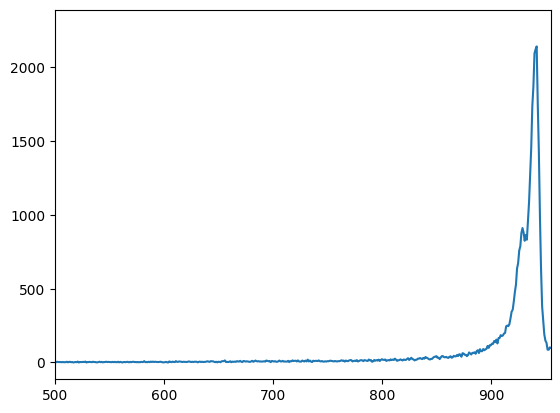

In [8]:
plt.plot(dfmca)
plt.xlim(500, 955)

In [9]:
total_counts = dfmca[300:955].sum().values[0]
activity = total_counts / mca_time
print(f"Total counts in Th-228 region: {total_counts}")
print(f"Measurement time: {mca_time} seconds")
print(f"Estimated activity: {activity:.2f} Bq")

Total counts in Th-228 region: 40970
Measurement time: 901.0 seconds
Estimated activity: 45.47 Bq


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime

# Th-228 Half-life in days
TH228_HALF_LIFE_DAYS = 1.9116 * 365.25
LAMBDA_TH228_DAYS = np.log(2) / TH228_HALF_LIFE_DAYS
LAMBDA_RA224_SEC = np.log(2) / (3.6319 * 24 * 3600)

def decay_correct_activity(a0: float, date0: str, date_target: str) -> float:
    """Decay corrects the Th-228 activity between two date strings (YYYY-MM-DD)."""
    t0 = datetime.strptime(date0, "%Y-%m-%d")
    t1 = datetime.strptime(date_target, "%Y-%m-%d")
    delta_days = (t1 - t0).days
    return a0 * np.exp(-LAMBDA_TH228_DAYS * delta_days)

def compute_desorption_probabilities(gamma_csv_path: Path, 
                                     mca_activity_bq: float, 
                                     mca_date: str, 
                                     gamma_date: str, 
                                     foil_geometry_fraction: float = 0.5) -> pd.DataFrame:
    """Unifies the Alpha and Gamma pipelines to find P_desorp."""
    
    # 1. Load Gamma Data
    df = pd.read_csv(gamma_csv_path)
    
    # 2. Decay correct the Th-228 source to the date of the Gamma measurement
    th228_true_bq = decay_correct_activity(mca_activity_bq, mca_date, gamma_date)
    
    # 3. Calculate metrics for each batch
    df['th228_source_bq'] = th228_true_bq
    
    # Convert capacity atoms to Bq
    df['ra224_foil_capacity_bq'] = df['max_ra_capacity'] * LAMBDA_RA224_SEC
    
    # P_desorp = Foil_Bq / (Source_Bq * Geometry)
    df['desorption_probability_pct'] = (df['ra224_foil_capacity_bq'] / (th228_true_bq * foil_geometry_fraction)) * 100
    
    return df

if __name__ == "__main__":
    gamma_summary = Path("artifacts/gamma_spectroscopy/accumulation_summary.csv")
    
    # Using your MCA ground truth
    final_results = compute_desorption_probabilities(
        gamma_csv_path=gamma_summary,
        mca_activity_bq=62.0,
        mca_date="2025-05-21",
        gamma_date="2026-03-03",
        foil_geometry_fraction=0.5
    )
    
    output_path = Path("artifacts/final_desorption_results.csv")
    final_results.to_csv(output_path, index=False)
    print(f"Unified analysis complete. P_desorp calculated. Saved to {output_path}")